✅ Config Loaded (File-based Split Mode).
[INFO] 13:52:45 - Scanning Data...
   + Loaded: merged_data_prepared.csv [TRAIN]
   + Loaded: model_test_devID109_15_percent_test_data_prepared.csv [TEST]
[INFO] 13:52:45 - Feature Engineering...
[INFO] 13:52:45 - Features: 17

🚀 HORIZON: +0.0 Hours
   Splitting by File (is_test flag)...
   Classes in Train Set: [0 1 2]
⚖️ Balancing Train Data...
   Original counts: Counter({np.int64(0): 53202, np.int64(1): 240, np.int64(2): 44})
🔍 Running Bayesian Optimization...
   🏆 Best Params: {'n_estimators': 241, 'learning_rate': 0.07852489672173349, 'max_depth': 3, 'subsample': 0.8463122274176654, 'colsample_bytree': 0.936032331118128, 'min_child_weight': 3, 'gamma': 0.44921749821370494}
   Training Final Model...

==================== TEST SET (Standard) - H0 ====================


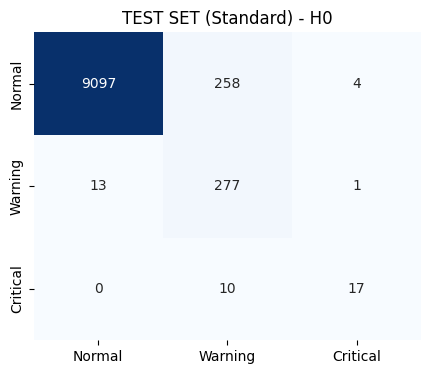

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99      9359
     Warning       0.51      0.95      0.66       291
    Critical       0.77      0.63      0.69        27

    accuracy                           0.97      9677
   macro avg       0.76      0.85      0.78      9677
weighted avg       0.98      0.97      0.97      9677



=== SUMMARY ===
   Horizon       Acc   F1_Crit
0        0  0.970445  0.693878


In [ ]:
# %%
# ====================================================================
# 1. IMPORTS & CONFIGURATION
# ====================================================================
import os
import glob
import time
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import optuna 
import xgboost as xgb
from tensorflow.keras.models import load_model 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, recall_score

import warnings
warnings.filterwarnings('ignore')

class Config:
    # --- PATHS ---
    DATA_DIR = "./dataMA/" 
    MODEL_DIR = "./model/xgboost_bayesMA/"
    SCALER_PATH = "./model/xgboost_bayes_scaler.save"
    
    ISO_MODEL_PATH = './../models/IsolationForest/model/iso_model2.joblib'
    ISO_SCALER_PATH = './../models/IsolationForest/model/iso_scaler2.joblib'
    LSTM_MODEL_PATH = './../models/LSTM_Autoencoders/lstm_autoencoder_model_fit.h5'
    LSTM_SCALER_PATH = './../models/LSTM_Autoencoders/scaler_fit.save'
    
    # --- SETTINGS ---
    HORIZONS = [0] 
    SEQUENCE_LENGTH = 1 
    
    # [KEY CHANGE] ใส่ Keyword ของไฟล์ Test ที่เตรียมไว้
    TEST_KEYWORDS = ['test', 'devID109'] 
    
    RAW_COLS = ['rain', 'soil', 'temp', 'humi', 'geo']
    LABEL_COL = 'label'
    LABEL_MAP = {'normal': 0, 'warning': 1, 'critical': 2}
    
    TARGET_SAMPLES = 5000  
    CLASS_WEIGHTS = {0: 1.0, 1: 2.5, 2: 5.0} 
    OPTUNA_TRIALS = 20
    
    XGB_FIXED = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'n_jobs': -1,
        'random_state': 42,
        'tree_method': 'hist',
        'early_stopping_rounds': 15
    }

cfg = Config()
if not os.path.exists(cfg.MODEL_DIR): os.makedirs(cfg.MODEL_DIR)
np.random.seed(42); random.seed(42)

def log(msg): print(f"[INFO] {time.strftime('%H:%M:%S')} - {msg}")
print("✅ Config Loaded (File-based Split Mode).")

# %%
# ====================================================================
# 2. DATA LOADING & ADVANCED FEATURE ENGINEERING
# ====================================================================
def load_data():
    log("Scanning Data...")
    files = glob.glob(os.path.join(cfg.DATA_DIR, "*.csv"))
    if not files: files = glob.glob(os.path.join(cfg.DATA_DIR, "**/*.csv"), recursive=True)
    
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df.columns = [str(c).lower().strip().replace('.1', '') for c in df.columns]
            
            rename_map = {'temperature':'temp', 'hum':'humi', 'humidity':'humi', 
                          'devid':'devID', 'time':'timestamp', 'date':'timestamp'}
            new_cols = {c: rename_map[c] for c in df.columns if c in rename_map}
            if new_cols: df = df.rename(columns=new_cols)
            
            df = df.loc[:, ~df.columns.duplicated()]
            
            if 'devID' in df.columns: 
                df['devID'] = df['devID'].astype(str).str.extract(r'(\d+)')[0].astype(float).fillna(0).astype(int)
            if 'timestamp' in df.columns: 
                df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
            
            for c in cfg.RAW_COLS: 
                if c not in df.columns: df[c] = 0.0
            
            # Check Keyword for Test Set
            filename = os.path.basename(f)
            df['is_test'] = any(k in filename for k in cfg.TEST_KEYWORDS)
            
            dfs.append(df)
            tag = "TEST" if df['is_test'].iloc[0] else "TRAIN"
            print(f"   + Loaded: {filename} [{tag}]")
        except Exception as e: pass
            
    return pd.concat(dfs, ignore_index=True) if dfs else None

def generate_features(df):
    log("Feature Engineering...")
    df = df.sort_values(['devID', 'timestamp']).reset_index(drop=True)
    df_list = []
    
    for dev, g in df.groupby('devID'):
        g = g.set_index('timestamp')
        g = g[~g.index.duplicated(keep='first')]
        
        if cfg.LABEL_COL in g.columns:
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].astype(str).str.lower().str.strip()
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].replace({'nan': 'normal', 'null': 'normal', '': 'normal'})
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].map(cfg.LABEL_MAP).fillna(0).astype(int)
        else: g[cfg.LABEL_COL] = 0

        if len(g) > 0:
            agg_dict = {c: 'mean' for c in cfg.RAW_COLS if c in g.columns}
            agg_dict[cfg.LABEL_COL] = 'max' 
            if 'is_test' in g.columns: agg_dict['is_test'] = 'max'
            g = g.resample('1T').agg(agg_dict)
        
        g[cfg.RAW_COLS] = g[cfg.RAW_COLS].interpolate(limit_direction='both').fillna(0)
        g[cfg.LABEL_COL] = g[cfg.LABEL_COL].fillna(0).astype(int)
        
        # --- CALCULATE FEATURES ---
        g['rain_ma_1h']  = g['rain'].rolling(60, min_periods=1).mean()    
        g['rain_ma_6h']  = g['rain'].rolling(360, min_periods=1).mean()   
        g['rain_ma_12h'] = g['rain'].rolling(720, min_periods=1).mean()   
        g['rain_ma_24h'] = g['rain'].rolling(1440, min_periods=1).mean()  
        g['soil_ma_4h']  = g['soil'].rolling(240, min_periods=1).mean()   
        g['soil_ma_8h']  = g['soil'].rolling(480, min_periods=1).mean()   
        g['soil_ma_12h'] = g['soil'].rolling(720, min_periods=1).mean()   
        g['soil_ma_16h'] = g['soil'].rolling(960, min_periods=1).mean()   
        g['geo_ma_2m'] = g['geo'].rolling(2, min_periods=1).mean()
        g['geo_ma_4m'] = g['geo'].rolling(4, min_periods=1).mean()
        g['geo_ma_6m'] = g['geo'].rolling(6, min_periods=1).mean()
        g['geo_ma_8m'] = g['geo'].rolling(8, min_periods=1).mean()
        g['devID'] = dev
        df_list.append(g.reset_index())
        
    return pd.concat(df_list, ignore_index=True).fillna(0)

df_train_raw = load_data()
df_proc = generate_features(df_train_raw)

# %%
# ====================================================================
# 3. PREPARATION
# ====================================================================
def create_sequences_vectorized(df, feature_cols, horizon):
    # [KEY CHANGE] คืนค่า is_tests กลับมาเพื่อใช้แบ่งไฟล์
    Xs, ys, is_tests = [], [], []
    for dev, g in df.groupby('devID'):
        data = g[feature_cols].values
        labels = g[cfg.LABEL_COL].shift(-horizon).values
        test_flag = g['is_test'].values # ดึง flag

        valid_len = len(g) - horizon
        if valid_len < cfg.SEQUENCE_LENGTH: continue
        
        windows = np.lib.stride_tricks.sliding_window_view(data[:valid_len], window_shape=(cfg.SEQUENCE_LENGTH, len(feature_cols))).squeeze()
        
        if windows.ndim == 1: windows = windows.reshape(-1, 1)
        elif windows.ndim == 2 and cfg.SEQUENCE_LENGTH > 1: windows = windows[np.newaxis, :, :]
            
        if windows.ndim == 3: windows_flat = windows.reshape(windows.shape[0], -1)
        else: windows_flat = windows 

        target_labels = labels[cfg.SEQUENCE_LENGTH-1 : valid_len]
        target_tests = test_flag[cfg.SEQUENCE_LENGTH-1 : valid_len] # ตัดให้เท่ากัน
        
        min_len = min(len(windows_flat), len(target_labels))
        Xs.append(windows_flat[:min_len])
        ys.append(target_labels[:min_len])
        is_tests.append(target_tests[:min_len])
        
    if not Xs: return np.array([]), np.array([]), np.array([])
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(is_tests)

def balance_data(X, y):
    print(f"   Original counts: {Counter(y)}")
    X_bal, y_bal = [], []
    for cls in np.unique(y):
        if np.isnan(cls): continue
        indices = np.where(y == cls)[0]
        count = len(indices)
        
        target = cfg.TARGET_SAMPLES
        replace = count < target
        n_samples = target if replace else count 
        if count > target * 2: n_samples = target * 2
        
        chosen_indices = np.random.choice(indices, n_samples, replace=replace)
        X_bal.append(X[chosen_indices]); y_bal.append(y[chosen_indices])
        
    X_bal = np.concatenate(X_bal); y_bal = np.concatenate(y_bal)
    perm = np.random.permutation(len(X_bal))
    return X_bal[perm], y_bal[perm]

# ====================================================================
# 4. VISUALIZATION & REPORTING HELPER
# ====================================================================
def evaluate_and_print(y_true, y_pred, title):
    print(f"\n{'='*20} {title} {'='*20}")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    class_names = ['Normal', 'Warning', 'Critical']
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.show()
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print(f"{'='*50}\n")

# ====================================================================
# 5. MAIN LOOP
# ====================================================================
def train_system():
    FINAL_FEATURES = [
        'rain', 'soil', 'temp', 'humi', 'geo',
        'rain_ma_1h', 'rain_ma_6h', 'rain_ma_12h', 'rain_ma_24h',
        'soil_ma_4h', 'soil_ma_8h', 'soil_ma_12h', 'soil_ma_16h',
        'geo_ma_2m', 'geo_ma_4m', 'geo_ma_6m', 'geo_ma_8m'
    ]
    
    log(f"Features: {len(FINAL_FEATURES)}")
    scaler = StandardScaler()

    # Convert Boolean
    df_proc['is_test'] = df_proc['is_test'].astype(bool)
    
    # Scale Data (Fit on Train Only or All? Using All for convenience in Lab)
    scaler.fit(df_proc[FINAL_FEATURES])
    df_proc[FINAL_FEATURES] = scaler.transform(df_proc[FINAL_FEATURES])
    joblib.dump(scaler, cfg.SCALER_PATH)
    
    # --- OPTIMIZATION FUNC ---
    def objective(trial, X_train, y_train, X_val, y_val, sample_weights):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 400),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 3),
        }
        full_params = {**cfg.XGB_FIXED, **params}
        model = xgb.XGBClassifier(**full_params)
        model.fit(X_train, y_train, sample_weight=sample_weights, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_val)
        rec_c = recall_score(y_val, preds, labels=[2], average=None, zero_division=0)[0] if 2 in y_val else 0
        f1_c  = f1_score(y_val, preds, labels=[2], average=None, zero_division=0)[0] if 2 in y_val else 0
        return (rec_c * 3.0) + f1_c 

    results_log = []

    for h in cfg.HORIZONS:
        print(f"\n🚀 HORIZON: +{h/60:.1f} Hours")
        
        # 1. Prepare Sequences & Get test_mask
        X_all, y_all, test_mask = create_sequences_vectorized(df_proc, FINAL_FEATURES, h)
        if len(X_all) == 0: continue
        
        # [KEY CHANGE] 2. Split by FILE (using test_mask)
        print("   Splitting by File (is_test flag)...")
        # ไฟล์ที่ไม่ใช่ Test = Train ทั้งหมด
        X_train_full = X_all[~test_mask]
        y_train_full = y_all[~test_mask]
        
        # ไฟล์ Test
        X_test = X_all[test_mask]
        y_test = y_all[test_mask]
        
        # เช็คความปลอดภัย: ถ้า Train set มีแค่ Normal จะเตือน
        unique_classes = np.unique(y_train_full)
        print(f"   Classes in Train Set: {unique_classes}")
        if len(unique_classes) < 2:
            print("⚠️ WARNING: Train set has only 1 Class! Model will fail to learn warning/critical.")
        
        # แบ่ง Train Full เป็น Train/Val (เพื่อให้ Optimize ได้)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=42
        )
        
        # 3. Balance
        print("⚖️ Balancing Train Data...")
        X_train_bal, y_train_bal = balance_data(X_train, y_train)
        
        safety_factor = 1.0 + (h/1440.0)
        sample_weights = np.array([cfg.CLASS_WEIGHTS[y] * safety_factor for y in y_train_bal])
        
        # 4. Optimize
        print(f"🔍 Running Bayesian Optimization...")
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='maximize')
        study.optimize(lambda trial: objective(trial, X_train_bal, y_train_bal, X_val, y_val, sample_weights), n_trials=cfg.OPTUNA_TRIALS)
        
        best_params = study.best_params
        print(f"   🏆 Best Params: {best_params}")
        
        # 5. Train Final
        print("   Training Final Model...")
        final_params = {**cfg.XGB_FIXED, **best_params}
        model = xgb.XGBClassifier(**final_params)
        model.fit(X_train_bal, y_train_bal, sample_weight=sample_weights, eval_set=[(X_val, y_val)], verbose=False)
        model.save_model(os.path.join(cfg.MODEL_DIR, f"xgboost_bayes_h{h}.json"))
        
        # 6. Eval
        y_test_pred = model.predict(X_test)
        evaluate_and_print(y_test, y_test_pred, f"TEST SET (Standard) - H{h}")
        
        # Log (Simplified)
        report = classification_report(y_test, y_test_pred, target_names=['Normal', 'Warning', 'Critical'], output_dict=True, zero_division=0)
        results_log.append({
            'Horizon': h, 
            'Acc': accuracy_score(y_test, y_test_pred), 
            'F1_Crit': report['Critical']['f1-score']
        })

    summary = pd.DataFrame(results_log)
    print("\n=== SUMMARY ===")
    print(summary)

if __name__ == "__main__":
    train_system()